# Exploratory Data Analysis - Recipe & Nutrition Dataset

**Project:** Recipe Dataset Analysis for College Presentation  
**Dataset:** AllRecipes-style recipe data with nutritional information  
**Purpose:** Understand patterns in recipes, ratings, and nutritional content

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from config import DATA_PATH

# Set style for professional-looking plots
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Load dataset
df = pd.read_csv("cuisine_updated.csv", index_col=0)
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 4466 rows, 9 columns


## 2. Dataset Overview

In [4]:
# First few rows
df.head(10)

,image_url,description,cuisine,course,diet,prep_time,ingredients,instructions,image_available
name,,,,,,,,,
Doddapatre Tambuli Recipe (Karpooravalli Thayir Pachadi),https://www.archanaskitchen.com/images/archana...,Doddapatre Tambuli Recipe is a popular healing...,Indian,Side Dish,Vegetarian,Total in 30 M,\n\n\t\t\t\t\t\t\t \t\t4 cups Indian borage (D...,"To begin making the Doddapatre Tambuli, first ...",1
Fish Tandoori Recipe,https://www.archanaskitchen.com/images/archana...,Have you ever tried out fish tandoori? Trust m...,North Indian Recipes,Appetizer,High Protein Non Vegetarian,Total in 80 M,\n\n\t\t\t\t\t\t\t \t\t1 Fish\t\t\t\t\t\t\t \t...,"To begin making the Fish Tandoori recipe, keep...",1
Arbi Shimla Mirch Sabzi Recipe – Colocasia Capsicum Sabzi,https://www.archanaskitchen.com/images/archana...,Arbi Shimla Mirch Sabzi Recipe is a variation ...,North Indian Recipes,Main Course,No Onion No Garlic (Sattvic),Total in 55 M,\n\n\t\t\t\t\t\t\t \t\t300 grams Colocasia roo...,To begin making the Arbi Shimla Mirch Sabzi Re...,1
Ambur Style Brinjal Curry Recipe,https://www.archanaskitchen.com/images/archana...,Brinjal Curry is prepared in different ways in...,Indian,Lunch,Vegetarian,Total in 20 M,\n\n\t\t\t\t\t\t\t \t\t5 Brinjal (Baingan / Eg...,To begin making the Ambur Style Brinjal Curry ...,1
Mavinakayi Menasinakai Curry Recipe - Raw Mango Coconut Curry,https://www.archanaskitchen.com/images/archana...,Mangalorean Mavinakayi Menasinakai Curry Recip...,Mangalorean,Side Dish,Vegetarian,Total in 35 M,\n\n\t\t\t\t\t\t\t \t\t1 cup Mango (Raw)\t\t\t...,To begin making Mangalorean Mavinakayi Menasin...,1
Cabbage And Carrot Thoran Recipe,https://www.archanaskitchen.com/images/archana...,Cabbage and Carrot Thoran Recipe is a simple K...,Kerala Recipes,Lunch,Vegetarian,Total in 40 M,\n\n\t\t\t\t\t\t\t \t\t3 Carrots (Gajjar)\t\t\...,To prepare this easy Cabbage And Carrot Thoran...,1
Konkani Style Mooga Ghushi Recipe-Sprouted Whole Green Gram In Tangy Coconut Gravy,https://www.archanaskitchen.com/images/archana...,‘Mooga Ghushi’ is a sprouted green gram-coconu...,Konkan,Lunch,Vegetarian,Total in 30 M,\n\n\t\t\t\t\t\t\t \t\t1/2 cup Green Moong Dal...,"To begin making the Mooga Ghushi recipe, first...",1
Chicken Sholay Kebab Recipe,https://www.archanaskitchen.com/images/archana...,Chicken Sholay Kebab Recipe is a finger lickin...,South Indian Recipes,Appetizer,Non Vegeterian,Total in 30 M,\n\n\t\t\t\t\t\t\t \t\t300 grams Boneless chic...,To begin making the Chicken Sholay Kebab Recip...,1
Beetroot Paneer Curry Recipe In Coconut Milk,https://www.archanaskitchen.com/images/archana...,Beetroot and Paneer Curry in Coconut milk is a...,Indian,Main Course,Vegetarian,Total in 55 M,\n\n\t\t\t\t\t\t\t \t\t200 grams Paneer (Homem...,To begin making the Beetroot and Paneer Curry ...,1


In [5]:
# Column information
print("=== COLUMN DESCRIPTIONS ===")
column_info = {
    'recipe_id': 'Unique identifier for each recipe',
    'recipe_name': 'Name of the recipe',
    'aver_rate': 'Average user rating (1-5 scale)',
    'image_url': 'URL to recipe image',
    'review_nums': 'Number of user reviews',
    'calories': 'Calories per serving (g)',
    'fat': 'Fat content (g)',
    'carbohydrates': 'Carbohydrates (g)',
    'protein': 'Protein (g)',
    'cholesterol': 'Cholesterol (mg)',
    'sodium': 'Sodium (mg)',
    'fiber': 'Dietary fiber (g)',
    'ingredients_list': 'List of ingredients (string)'
}
for col, desc in column_info.items():
    print(f"  {col}: {desc}")

=== COLUMN DESCRIPTIONS ===
  recipe_id: Unique identifier for each recipe
  recipe_name: Name of the recipe
  aver_rate: Average user rating (1-5 scale)
  image_url: URL to recipe image
  review_nums: Number of user reviews
  calories: Calories per serving (g)
  fat: Fat content (g)
  carbohydrates: Carbohydrates (g)
  protein: Protein (g)
  cholesterol: Cholesterol (mg)
  sodium: Sodium (mg)
  fiber: Dietary fiber (g)
  ingredients_list: List of ingredients (string)


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4466 entries, Doddapatre Tambuli Recipe (Karpooravalli Thayir Pachadi) to Dal Chenchki ( Red Lentils with Shallots)
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   image_url        4466 non-null   object
 1   description      4466 non-null   object
 2   cuisine          4458 non-null   object
 3   course           4424 non-null   object
 4   diet             4424 non-null   object
 5   prep_time        4454 non-null   object
 6   ingredients      4466 non-null   object
 7   instructions     4466 non-null   object
 8   image_available  4466 non-null   int64 
dtypes: int64(1), object(8)
memory usage: 348.9+ KB


In [7]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Percentage
course,42,0.94
diet,42,0.94
prep_time,12,0.27
cuisine,8,0.18


## 3. Statistical Summary

In [8]:
df.describe()

,image_available
count,4466.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [9]:
df['prep_time_minutes'] = (
    df['prep_time']
    .str.extract(r'(\d+)')
    .astype(float)
)

df[['prep_time_minutes']].describe()


,prep_time_minutes
count,4454.000000
mean,56.377189
std,73.075811
min,0.000000
25%,30.000000
50%,40.000000
75%,55.000000
max,1470.000000


In [10]:
print(df.columns)


Index(['image_url', 'description', 'cuisine', 'course', 'diet', 'prep_time',
       'ingredients', 'instructions', 'image_available', 'prep_time_minutes'],
      dtype='object')


## 4. Univariate Analysis - Distributions

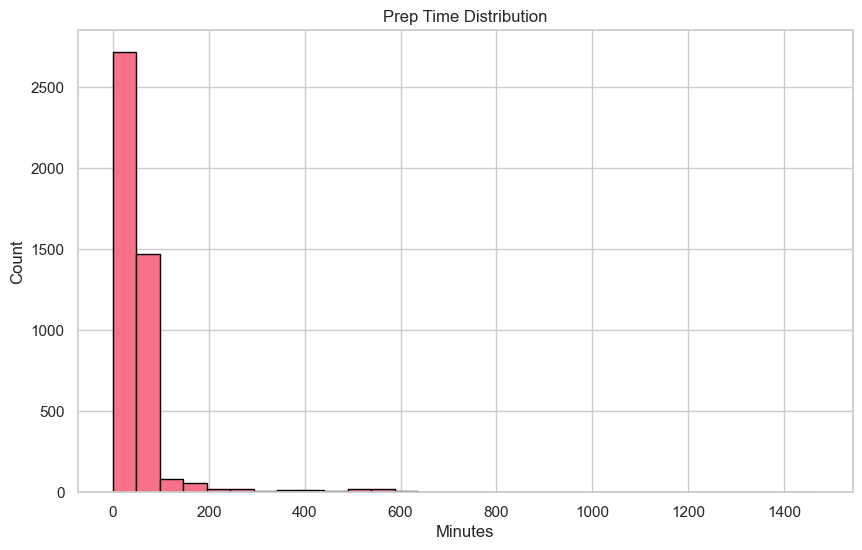

In [11]:
plt.hist(df['prep_time_minutes'].dropna(), bins=30, edgecolor='black')
plt.title('Prep Time Distribution')
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65279 (\N{ZERO WIDTH NO-BREAK SPACE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


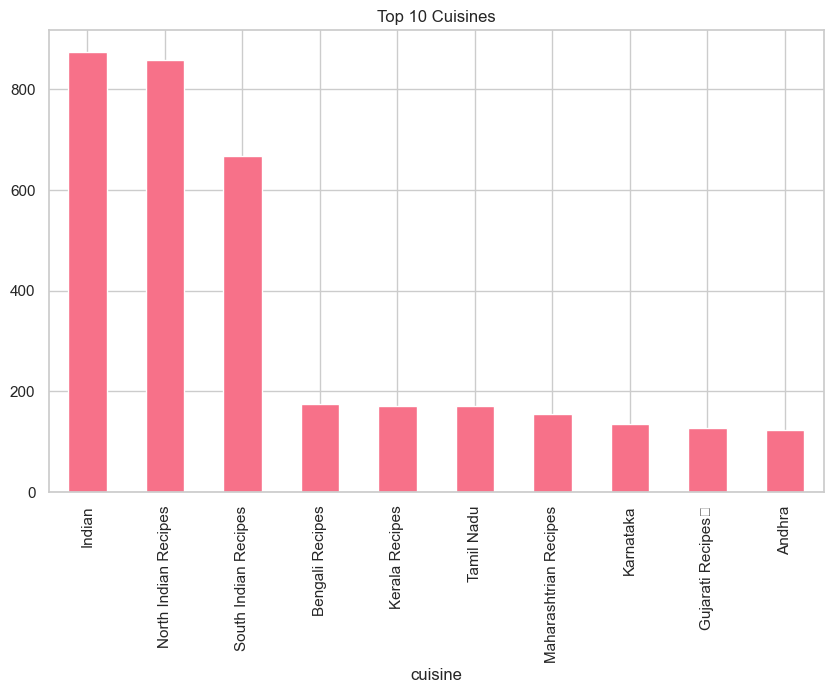

In [12]:
df['cuisine'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Cuisines')
plt.show()


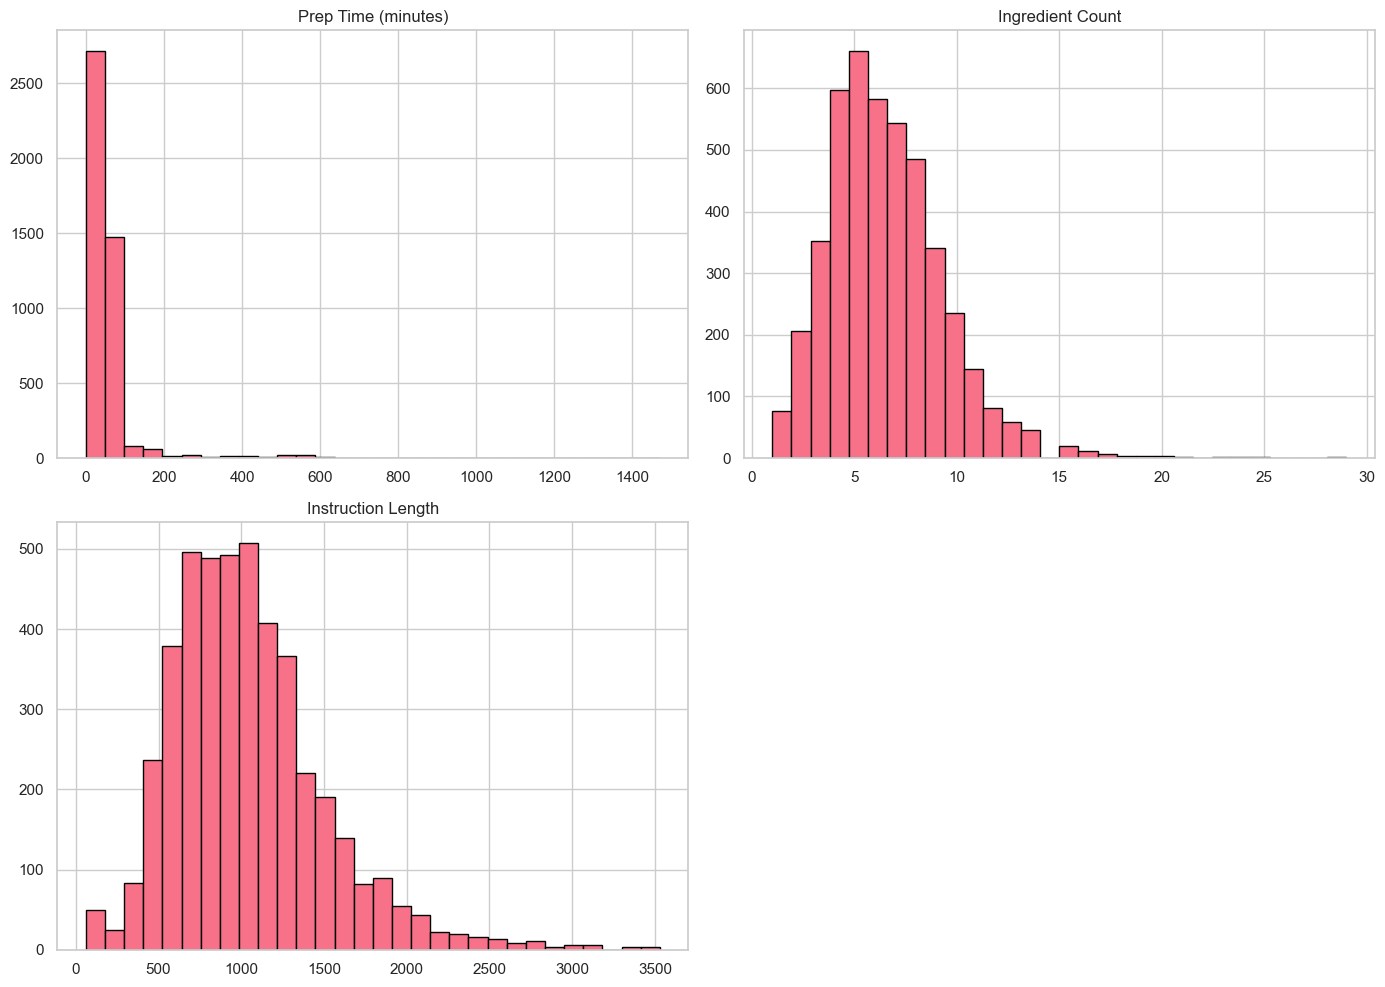

In [13]:
# Create new numeric features
df['ingredient_count'] = df['ingredients'].str.split(',').str.len()
df['instruction_length'] = df['instructions'].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['prep_time_minutes'].dropna(), bins=30, edgecolor='black')
axes[0,0].set_title('Prep Time (minutes)')

axes[0,1].hist(df['ingredient_count'].dropna(), bins=30, edgecolor='black')
axes[0,1].set_title('Ingredient Count')

axes[1,0].hist(df['instruction_length'].dropna(), bins=30, edgecolor='black')
axes[1,0].set_title('Instruction Length')

axes[1,1].axis('off')  # if you only have 3 plots

plt.tight_layout()
plt.show()


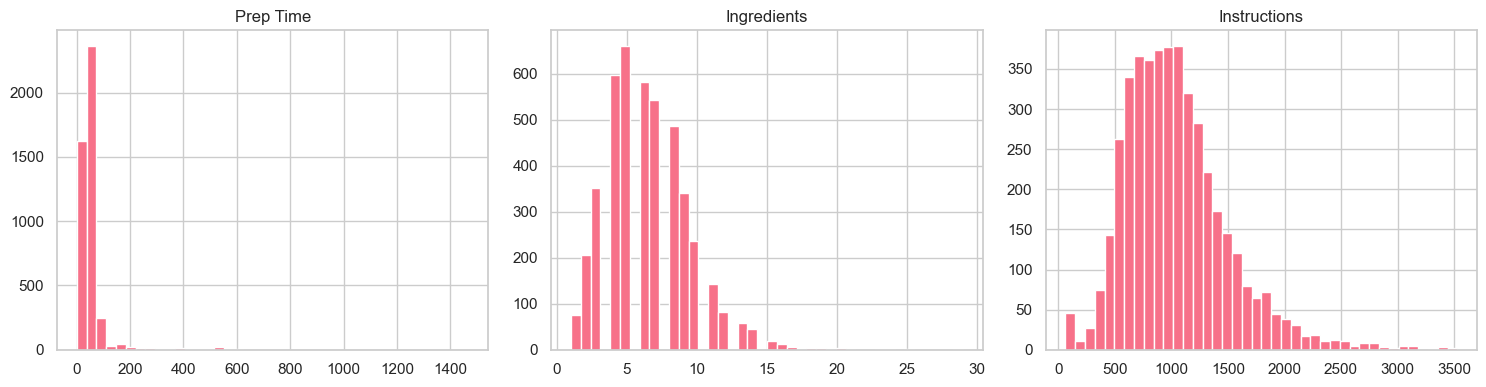

In [14]:
df['ingredient_count'] = df['ingredients'].str.split(',').str.len()
df['instruction_length'] = df['instructions'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['prep_time_minutes'].dropna(), bins=40); axes[0].set_title('Prep Time')
axes[1].hist(df['ingredient_count'].dropna(), bins=40); axes[1].set_title('Ingredients')
axes[2].hist(df['instruction_length'].dropna(), bins=40); axes[2].set_title('Instructions')

plt.tight_layout()
plt.show()


## 5. Bivariate Analysis - Correlations

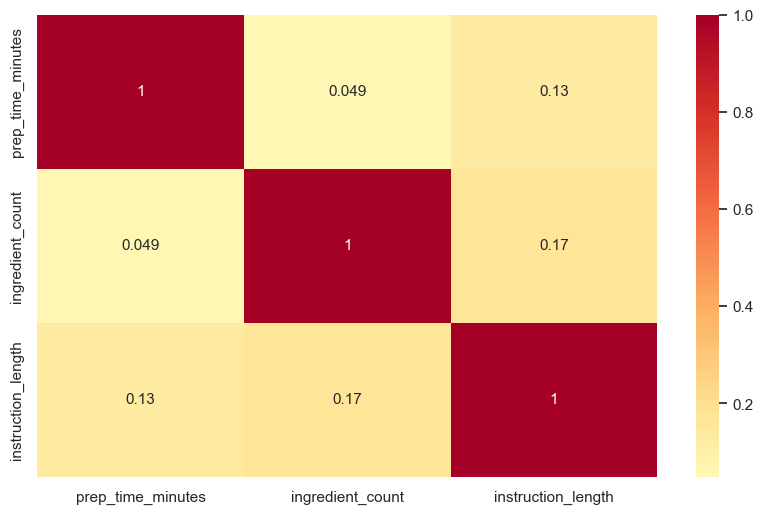

In [15]:
numeric_cols = ['prep_time_minutes', 'ingredient_count', 'instruction_length']

corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0)
plt.show()


In [16]:
numeric_cols = ['aver_rate','review_nums','calories','fat','carbohydrates','protein','cholesterol','sodium','fiber']

existing_cols = [c for c in numeric_cols if c in df.columns]

if existing_cols:
    corr_matrix = df[existing_cols].corr()
    sns.heatmap(corr_matrix, annot=True)
else:
    print("No numeric columns found for correlation.")


No numeric columns found for correlation.


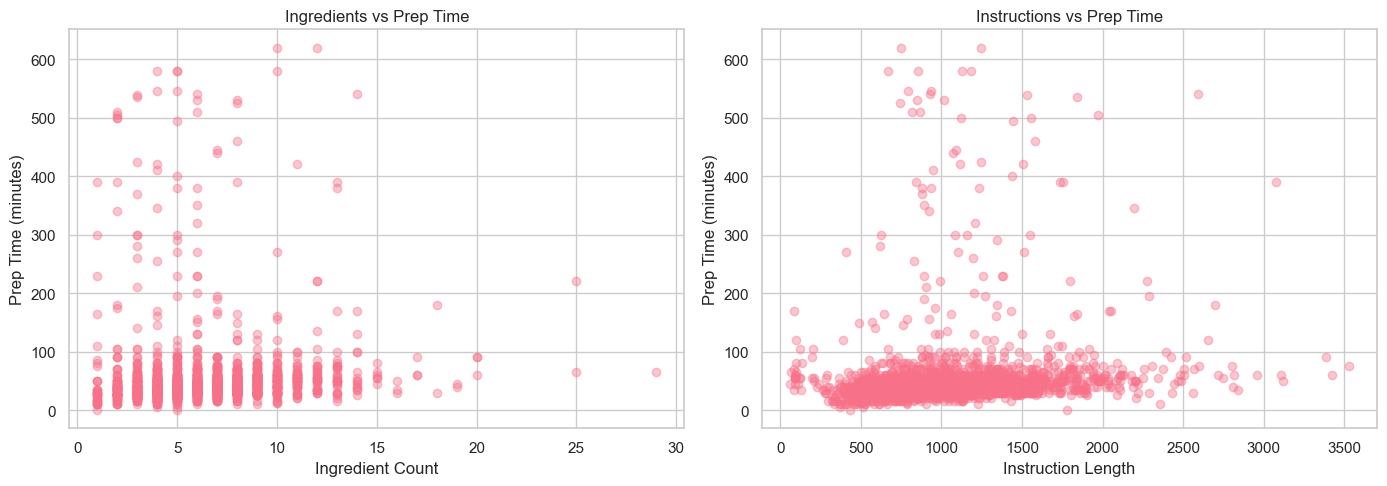

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(min(2000, len(df)), random_state=42)

axes[0].scatter(sample['ingredient_count'], sample['prep_time_minutes'], alpha=0.4)
axes[0].set_xlabel('Ingredient Count')
axes[0].set_ylabel('Prep Time (minutes)')
axes[0].set_title('Ingredients vs Prep Time')

axes[1].scatter(sample['instruction_length'], sample['prep_time_minutes'], alpha=0.4)
axes[1].set_xlabel('Instruction Length')
axes[1].set_ylabel('Prep Time (minutes)')
axes[1].set_title('Instructions vs Prep Time')

plt.tight_layout()
plt.show()


## 6. Key Insights - Top & Bottom Recipes

In [18]:
# Top 10 highest-rated recipes (with minimum 5 reviews)
min_reviews = 5

top_rated = (
    df[df['review_nums'] >= min_reviews]
    .nlargest(10, 'aver_rate')[['recipe_name', 'aver_rate', 'review_nums', 'calories']]
)

print("Top 10 Highest-Rated Recipes (min 5 reviews):")
print(top_rated)


KeyError: 'review_nums'

In [50]:
# Most reviewed recipes
most_reviewed = df.nlargest(10, 'review_nums')[['recipe_name', 'aver_rate', 'review_nums', 'calories']]
print("Top 10 Most-Reviewed Recipes:")
most_reviewed

KeyError: 'review_nums'

In [ ]:
# Calorie ranges
print("=== CALORIE ANALYSIS ===")
print(f"Lowest calorie recipe: {df.loc[df['calories'].idxmin(), 'recipe_name']} ({df['calories'].min()} cal)")
print(f"Highest calorie recipe: {df.loc[df['calories'].idxmax(), 'recipe_name']} ({df['calories'].max()} cal)")
print(f"\nRecipes under 200 cal: {(df['calories'] < 200).sum()}")
print(f"Recipes 200-400 cal: {((df['calories'] >= 200) & (df['calories'] < 400)).sum()}")
print(f"Recipes 400-600 cal: {((df['calories'] >= 400) & (df['calories'] < 600)).sum()}")
print(f"Recipes over 600 cal: {(df['calories'] >= 600).sum()}")

## 7. Ingredients Analysis

Ingredients per recipe:
count    4466.000000
mean        6.440215
std         2.983363
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        29.000000
Name: ingredient_count, dtype: float64


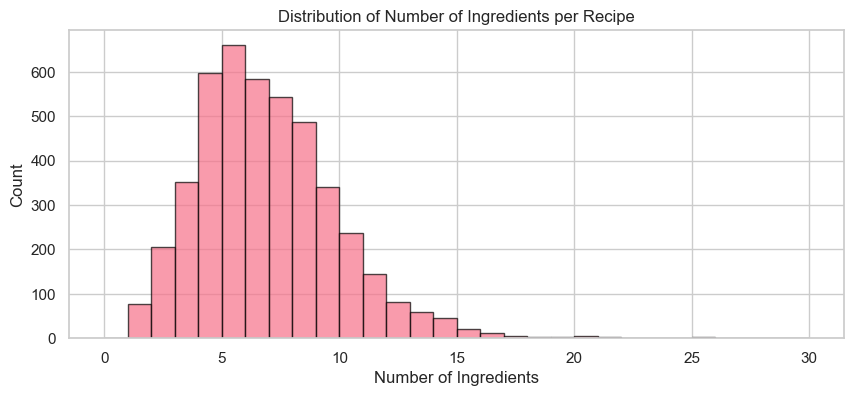

In [36]:
def count_ingredients(ing_str):
    if pd.isna(ing_str):
        return 0
    return len(ing_str.split(','))

df['ingredient_count'] = df['ingredients'].apply(count_ingredients)

print("Ingredients per recipe:")
print(df['ingredient_count'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['ingredient_count'], bins=range(0, int(df['ingredient_count'].max())+2), edgecolor='black', alpha=0.7)
plt.title('Distribution of Number of Ingredients per Recipe')
plt.xlabel('Number of Ingredients')
plt.ylabel('Count')
plt.show()


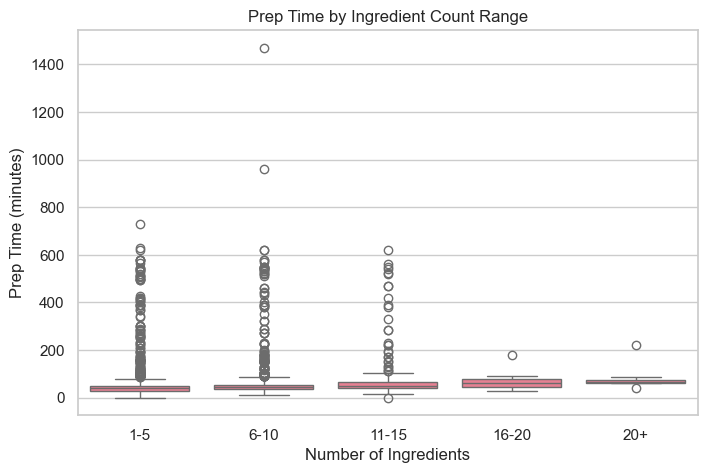

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=pd.cut(df['ingredient_count'],
             bins=[0, 5, 10, 15, 20, 100],
             labels=['1-5', '6-10', '11-15', '16-20', '20+']),
    y='prep_time_minutes',
    data=df
)

plt.title('Prep Time by Ingredient Count Range')
plt.xlabel('Number of Ingredients')
plt.ylabel('Prep Time (minutes)')
plt.show()


## 8. Summary Statistics for Presentation

In [40]:
print("="*50)
print("EDA SUMMARY - KEY NUMBERS FOR PRESENTATION")
print("="*50)
print(f"Total recipes: {len(df):,}")
print(f"Average prep time: {df['prep_time_minutes'].mean():.1f} minutes")
print(f"Median prep time: {df['prep_time_minutes'].median():.0f} minutes")
print(f"Average ingredients per recipe: {df['ingredient_count'].mean():.1f}")
print(f"Average instruction length: {df['instruction_length'].mean():.0f} characters")
print("="*50)


EDA SUMMARY - KEY NUMBERS FOR PRESENTATION
Total recipes: 4,466
Average prep time: 56.4 minutes
Median prep time: 40 minutes
Average ingredients per recipe: 6.4
Average instruction length: 1042 characters


C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65279 (\N{ZERO WIDTH NO-BREAK SPACE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


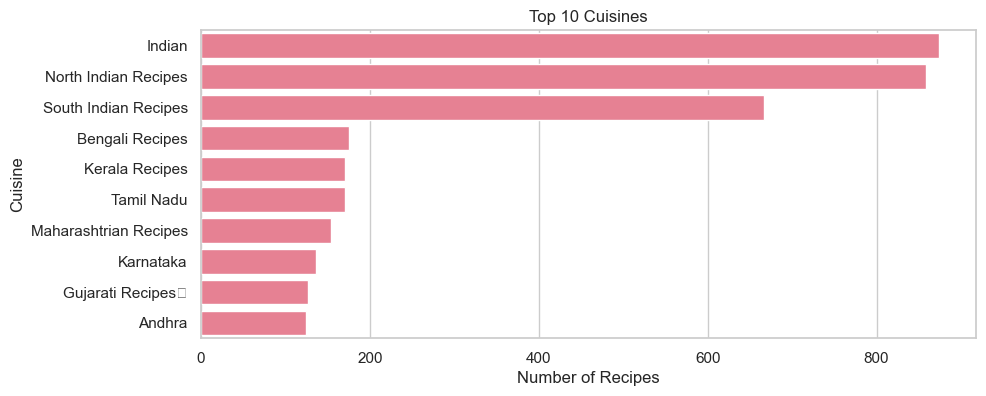

In [41]:
top_cuisines = df['cuisine'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines")
plt.xlabel("Number of Recipes")
plt.ylabel("Cuisine")
plt.show()


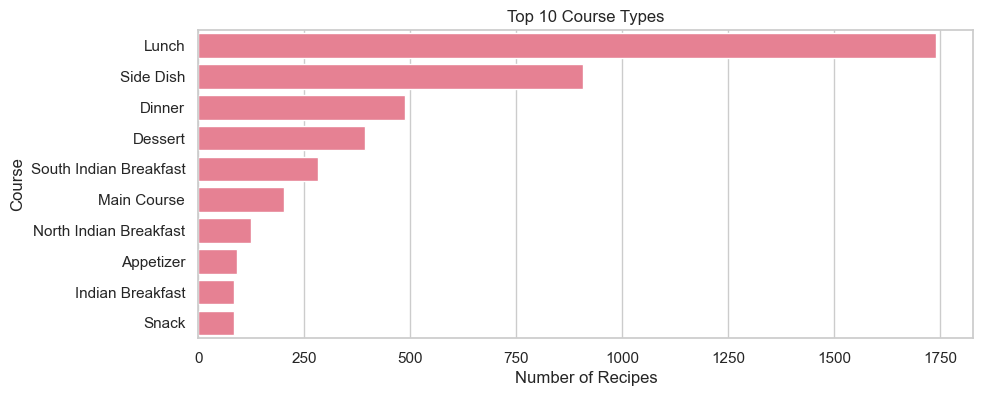

In [42]:
top_courses = df['course'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_courses.values, y=top_courses.index)
plt.title("Top 10 Course Types")
plt.xlabel("Number of Recipes")
plt.ylabel("Course")
plt.show()


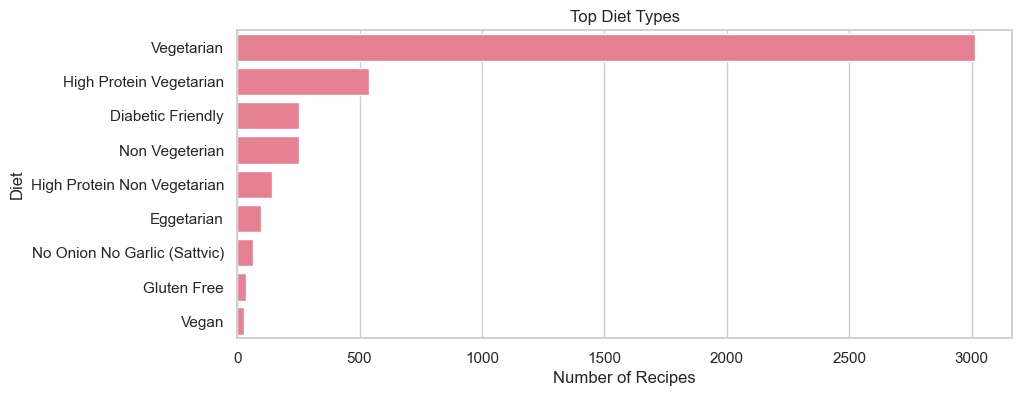

In [43]:
top_diets = df['diet'].value_counts().head(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_diets.values, y=top_diets.index)
plt.title("Top Diet Types")
plt.xlabel("Number of Recipes")
plt.ylabel("Diet")
plt.show()


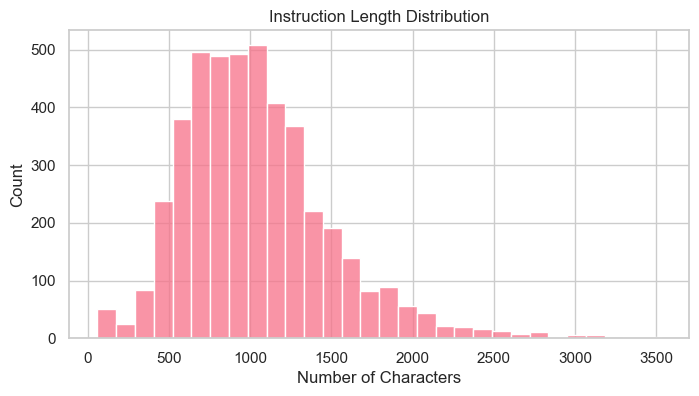

In [45]:
plt.figure(figsize=(8,4))
sns.histplot(df['instruction_length'], bins=30)
plt.title("Instruction Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Count")
plt.show()


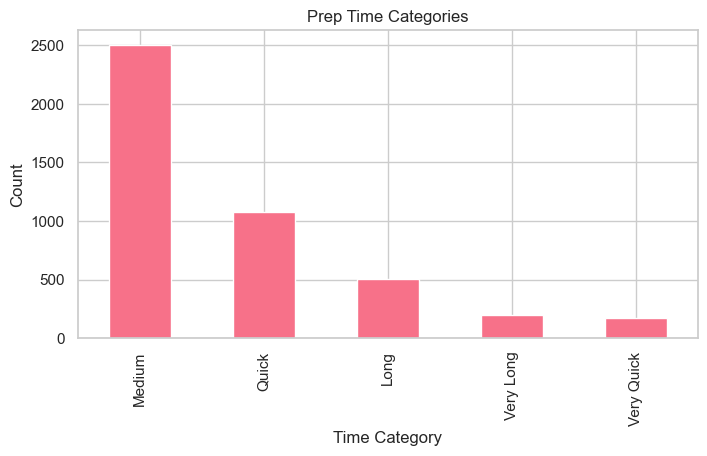

In [46]:
df['time_category'] = pd.cut(
    df['prep_time_minutes'],
    bins=[0, 15, 30, 60, 120, 10000],
    labels=['Very Quick', 'Quick', 'Medium', 'Long', 'Very Long']
)

df['time_category'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Prep Time Categories")
plt.xlabel("Time Category")
plt.ylabel("Count")
plt.show()
